# uncertainty-gate: calibrated uncertainty as a trust layer

One claim, one chart: a model that attaches **calibrated, guarantee-backed uncertainty** to its answers — and abstains when unsure — becomes dramatically more reliable on the answers it does give.

The story in four acts: **broken → calibrated → guaranteed → gated.**

This notebook produces the same four artefacts as `python -m src.pipeline`, using the same importable functions from `src/`.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src import calibration as cal
from src import conformal, selective
from src.pipeline import load_config, set_seed, _load_matrices, OUTPUTS
from src.plots import plot_reliability, plot_risk_coverage

cfg = load_config()
rng = set_seed(cfg['seed'])
print('dataset:', cfg['dataset'])

dataset: arc


## Act 0 — data and model

`_load_matrices` returns probability matrices for a calibration split and a test split. For `tabular` this is a gradient-boosted classifier on Covertype (no LLM needed); for `arc`/`mmlu` it is an LLM's next-token distribution over the options A–D (cached to `outputs/cache/` after the first run).

In [2]:
d = _load_matrices(cfg)
y_test = d['y_test']
pred = d['P_test'].argmax(axis=1)
correct = (pred == y_test).astype(float)
conf_raw = d['P_test'].max(axis=1)
print(f"cal={len(d['y_cal'])}  test={len(y_test)}  accuracy={correct.mean():.3f}")

/Users/rishisaravanan/Projects/calibrationLayer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[data] dropped non-4-option questions: {'cal': 4, 'test': 7}
cal=295  test=1165  accuracy=0.834


## Act 1 — broken: confidence is not probability

The model's raw `p_max` is *miscalibrated*: when it says 0.9 it is not right 90% of the time. Expected calibration error (ECE) quantifies the gap.

In [3]:
ece_raw = cal.ece(conf_raw, correct)
print(f'raw ECE = {ece_raw:.4f}')

raw ECE = 0.1197


## Act 2 — calibrated: temperature scaling

One scalar `T`, fit by minimising NLL **on the calibration split only**, rescales the logits. Accuracy is untouched (argmax is invariant); only the confidence becomes honest. ECE is evaluated on the held-out test split.

T = 2.694   ECE 0.1197 -> 0.0320


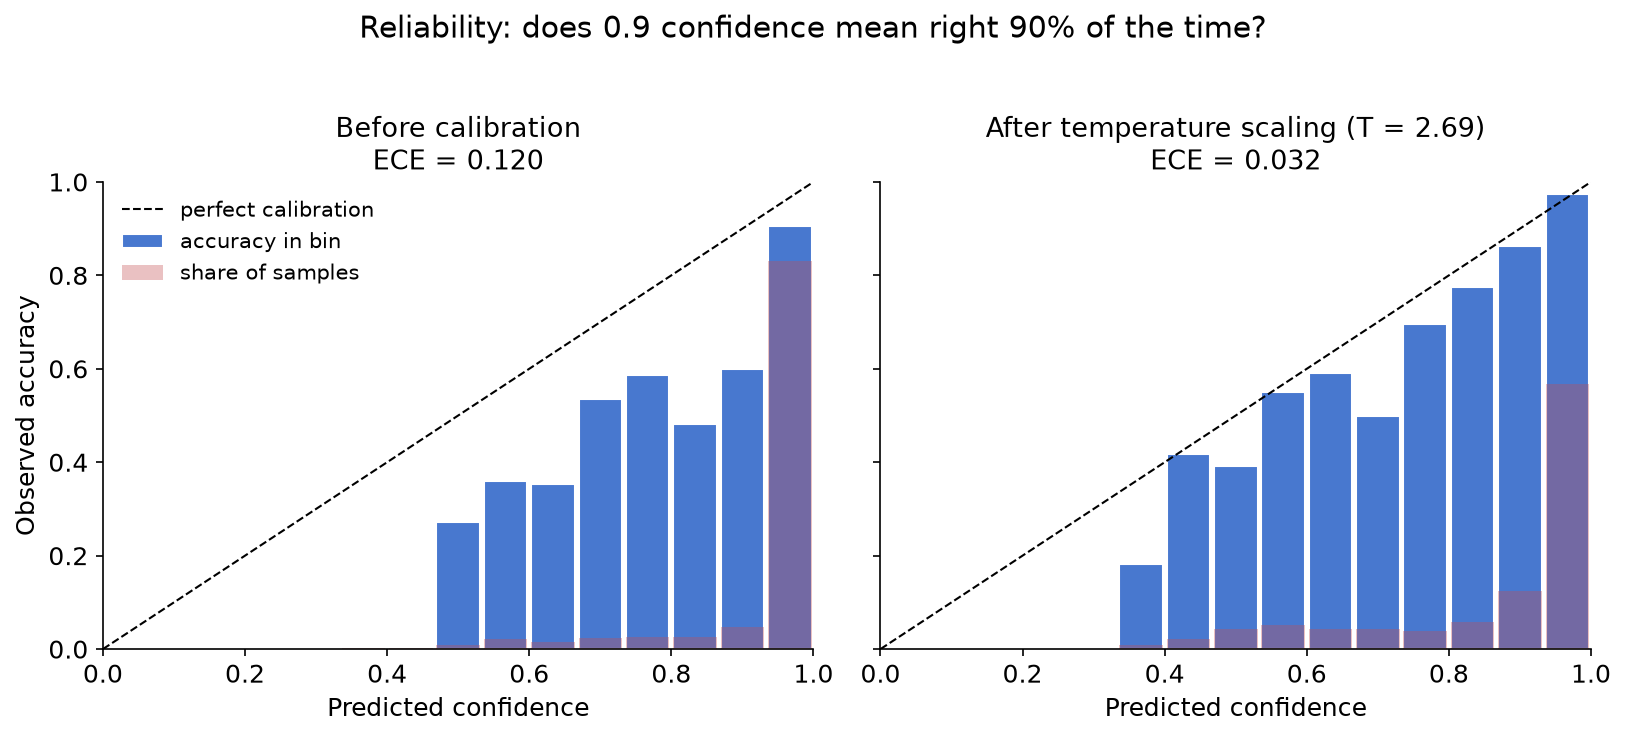

In [4]:
T = cal.fit_temperature(d['logits_cal'], d['y_cal'])
P_test_cal = cal.apply_temperature(d['logits_test'], T)
P_cal_cal = cal.apply_temperature(d['logits_cal'], T)
conf_cal = P_test_cal.max(axis=1)
ece_after = cal.ece(conf_cal, correct)
print(f'T = {T:.3f}   ECE {ece_raw:.4f} -> {ece_after:.4f}')
plot_reliability(conf_raw, conf_cal, correct, ece_raw, ece_after, T, OUTPUTS / 'reliability.png')
Image(OUTPUTS / 'reliability.png', width=900)

## Act 3 — guaranteed: split conformal prediction

Calibrated confidence is honest *on average*; conformal prediction upgrades that to a **distribution-free guarantee**: prediction sets that contain the true answer with probability ≥ 1 − α, assuming only exchangeability. The whole construction is ~30 lines in `src/conformal.py`, and `tests/test_conformal.py` verifies the guarantee over hundreds of random splits.

Below: the guarantee checked empirically on this dataset, for both score functions (LAC and APS).

In [5]:
report = conformal.coverage_check(P_cal_cal, d['y_cal'], P_test_cal, y_test, cfg['alpha'], rng=rng)
with open(OUTPUTS / 'coverage_check.json', 'w') as f:
    json.dump(report, f, indent=2)
rows = [{'method': m, 'alpha': a, **r} for m, d_ in report.items() for a, r in d_.items()]
pd.DataFrame(rows)

,method,alpha,target_coverage,empirical_coverage,mean_set_size,qhat
0,lac,0.05,0.95,0.9373,1.3863,0.900487
1,lac,0.1,0.90,0.8936,1.1794,0.773124
2,lac,0.2,0.80,0.7614,0.8446,0.356284
3,aps,0.05,0.95,0.9382,1.5957,0.954814
4,aps,0.1,0.90,0.8695,1.2773,0.893500
5,aps,0.2,0.80,0.7931,1.0979,0.825433


Empirical coverage sits at (or a hair above) the target `1 − alpha` for every row — the guarantee is real, not a slogan.

A set of size 1 is a confident answer; a bigger set is an honest 'not sure'. That is the abstention rule: **answer only on singletons.**

In [6]:
sets, qhat = conformal.predict_sets(P_cal_cal, d['y_cal'], P_test_cal, alpha=cfg['alpha'][1], method='lac')
abstain = conformal.abstain_mask_from_sets(sets)
answered = ~abstain
print(f'answered {answered.mean():.1%} of questions; accuracy on answered: {correct[answered].mean():.3f} vs overall {correct.mean():.3f}')

answered 82.8% of questions; accuracy on answered: 0.899 vs overall 0.834


## Act 4 — gated: the risk–coverage curve

Rank questions by confidence, answer the top fraction (*coverage*), measure error on what was answered (*risk*). This is the money chart: error collapses as the model is allowed to abstain.

At 70% coverage, error drops from 16.6% (answer everything) to 4.7% (calibrated confidence gate); raw-confidence gating gives 4.7%.


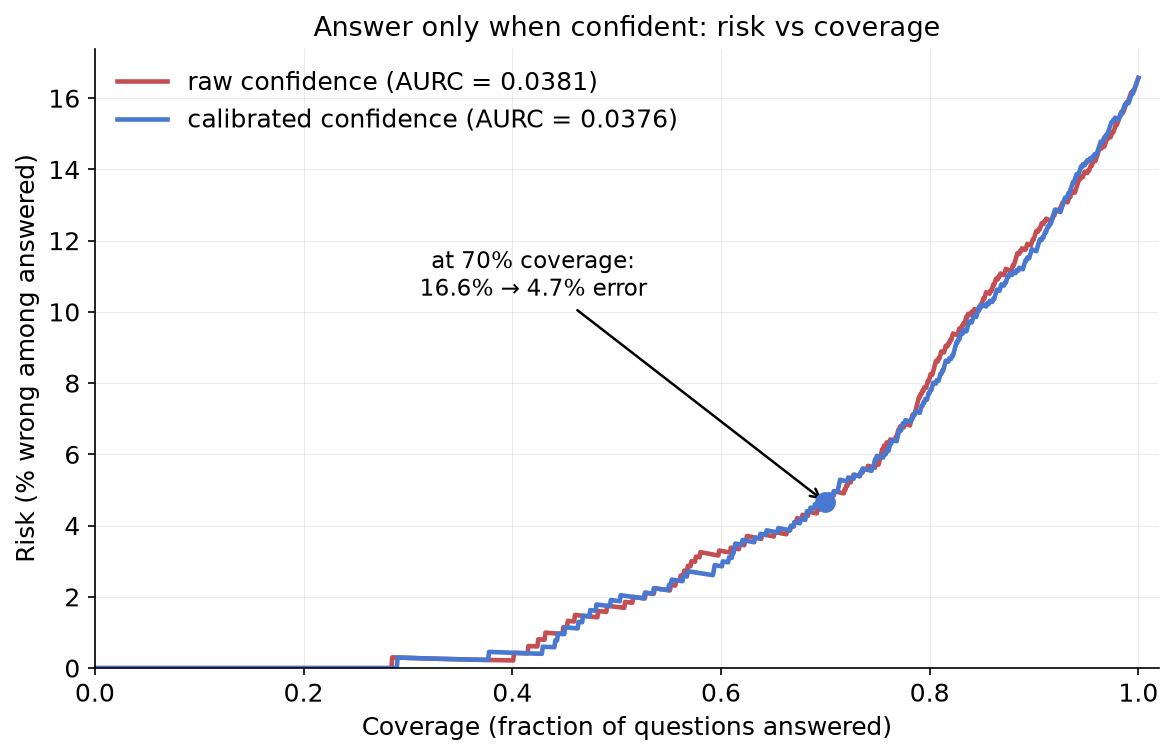

In [7]:
cov_raw, risk_raw = selective.risk_coverage(conf_raw, correct)
cov_c, risk_c = selective.risk_coverage(conf_cal, correct)
aurc_raw = selective.aurc(cov_raw, risk_raw)
aurc_cal = selective.aurc(cov_c, risk_c)
head = selective.headline(conf_raw, conf_cal, correct, 0.70)
plot_risk_coverage({'raw': (cov_raw, risk_raw, aurc_raw), 'calibrated': (cov_c, risk_c, aurc_cal)}, head, OUTPUTS / 'risk_coverage.png')
print(head['sentence'])
Image(OUTPUTS / 'risk_coverage.png', width=750)

## Caught in the act

Concrete cases the model got *confidently wrong* — and the layer flagged (set size ≥ 2 or calibrated confidence below the abstention threshold). Generated as `outputs/caught_examples.md` by the pipeline:

In [8]:
from src.pipeline import run
metrics = run()  # idempotent + cache-aware: writes all four artefacts + metrics.json
display(Markdown((OUTPUTS / 'caught_examples.md').read_text()))

[pipeline] dataset=arc  seed=42


[data] dropped non-4-option questions: {'cal': 4, 'test': 7}
[pipeline] cal=295  test=1165  classes=4
[calibration] T=2.694  ECE raw=0.1197 -> calibrated=0.0320

=== uncertainty-gate summary ===
accuracy (full coverage): 0.834
ECE: 0.1197 -> 0.0320 (T = 2.694)
AURC: raw 0.0381 -> calibrated 0.0376
coverage[lac, alpha=0.05]: target 0.95, empirical 0.937, mean set size 1.39
coverage[lac, alpha=0.1]: target 0.90, empirical 0.894, mean set size 1.18
coverage[lac, alpha=0.2]: target 0.80, empirical 0.761, mean set size 0.84
coverage[aps, alpha=0.05]: target 0.95, empirical 0.938, mean set size 1.60
coverage[aps, alpha=0.1]: target 0.90, empirical 0.870, mean set size 1.28
coverage[aps, alpha=0.2]: target 0.80, empirical 0.793, mean set size 1.10
At 70% coverage, error drops from 16.6% (answer everything) to 4.7% (calibrated confidence gate); raw-confidence gating gives 4.7%.


# Confidently wrong — and caught

Cases where the base model was wrong with high raw confidence, but the uncertainty layer flagged them: conformal set size >= 2 (alpha = 0.1) or calibrated confidence below the abstention threshold (0.856, the cutoff for 70% coverage).

## Example 1

**Question:** Which of these is an example of water changing from water vapor to liquid?

- A. moisture forming on a mirror when you breathe on it  <- correct
- B. sweat forming on your body when you exercise
- C. ice cubes melting when you put them in a warm liquid  <- model's answer
- D. rivers drying up during a very hot summer

Raw confidence **0.95** — and wrong. Flagged because conformal set {A, C} (size 2) is not a singleton; and calibrated confidence 0.74 < abstention threshold 0.86 -> **abstain / escalate**.

## Example 2

**Question:** A pitcher throws a 0.15 kg baseball at 43 40 m/s towards the catcher. What is the momentum of the baseball while moving at 40 m/s?

- A. 0.025 kg x m/s
- B. 3.8 kg x m/s  <- model's answer
- C. 6.0 kg x m/s  <- correct
- D. 270 kg x m/s

Raw confidence **0.95** — and wrong. Flagged because conformal set {B, C} (size 2) is not a singleton; and calibrated confidence 0.70 < abstention threshold 0.86 -> **abstain / escalate**.

## Example 3

**Question:** Single-celled organisms that cause disease can be found in which domains?

- A. Archaea and Eukarya
- B. Bacteria and Eukarya  <- correct
- C. Archaea and Bacteria  <- model's answer
- D. Archaea, Bacteria, and Eukarya

Raw confidence **0.95** — and wrong. Flagged because conformal set {C, D} (size 2) is not a singleton; and calibrated confidence 0.73 < abstention threshold 0.86 -> **abstain / escalate**.


## Wrap-up

- **Calibrated:** temperature scaling makes stated confidence match observed accuracy (ECE drops several-fold).
- **Guaranteed:** split conformal sets hit their promised coverage at every α — verified here and in `tests/test_conformal.py`.
- **Gated:** abstaining on the uncertain tail collapses error on the answers actually given.

Limitations: the guarantee is *marginal* (not per-group/conditional), rests on exchangeability of calibration and test data, and correctness here is exact-match MCQ only.